In [ ]:
!pip install gdown

In [ ]:
# Data loading and processing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Packages for creating model
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Download files
import gdown

In [ ]:
# Download the file
gdown.download(
    'https://drive.google.com/uc?id=1i-wBVudoIxRDo9_DGQCM6kH28kX0SUvH',
    'bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv',
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1i-wBVudoIxRDo9_DGQCM6kH28kX0SUvH
From (redirected): https://drive.google.com/uc?id=1i-wBVudoIxRDo9_DGQCM6kH28kX0SUvH&confirm=t&uuid=1a821f3c-2997-42f8-bca0-0a3e9c51caef
To: /content/bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv
100%|██████████| 318M/318M [00:03<00:00, 97.1MB/s]


'bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv'

In [ ]:
# Read data from csv
raw_data = pd.read_csv('bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv')

In [ ]:
raw_data.head()

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1325317920,4.39,4.39,4.39,4.39,0.455581,2.0,4.39
1,1325317980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1325318040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1325318100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1325318160,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = raw_data[['Timestamp', 'Close']].copy()
df.rename(columns={'Timestamp': 'date', 'Close': 'price'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], unit='s')

# Normalize the 'date' to only include the date part (removing the time part)
df['date'] = df['date'].dt.date

# Now aggregate by the normalized date
df = df.groupby('date').agg({'price': 'max'}).reset_index()

df.head()

,date,price
0,2011-12-31,4.482500
1,2012-01-01,4.806667
2,2012-01-02,5.000000
3,2012-01-03,5.252500
4,2012-01-04,5.223333


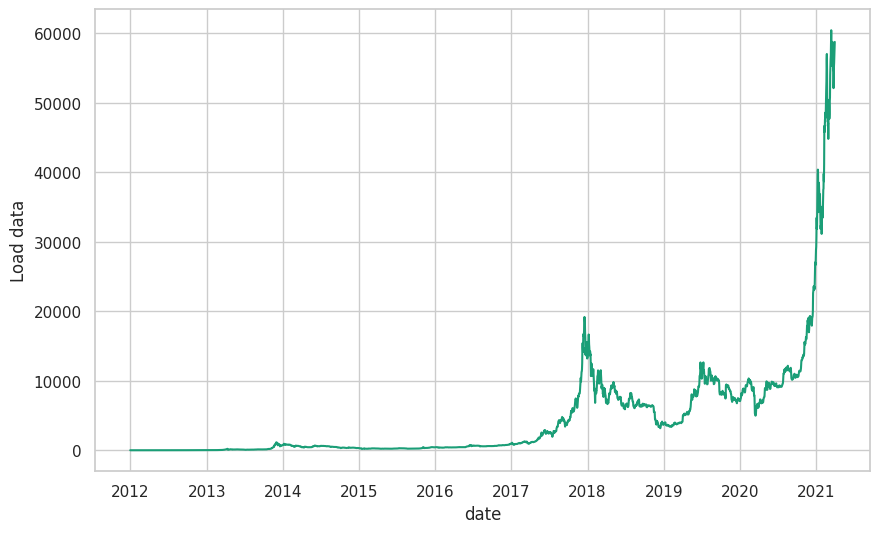

In [ ]:
# Visualization of data
sns.set_theme(style='whitegrid', palette='Dark2')
plt.figure(figsize=(10,6), dpi=100)
plt.plot(df['date'], df['price'])
plt.xlabel('date');
plt.ylabel('Load data');

In [ ]:
# Split interval. Using 5% data for test and 95% for training
split = int(len(df)*0.95)

# Training Set
x_train = df['price'][:split]

# Test set
x_validation = df['price'][split:]

In [ ]:
def segmented_dataset(load, Window, batches, shuffle_buffer):
    # Create a dataset from the input data
    data_gen = tf.data.Dataset.from_tensor_slices(load)

    # Create overlapping windows and flatten them into batches
    data_gen = data_gen.window(Window + 1, shift=1, drop_remainder=True)
    data_gen = data_gen.flat_map(lambda window: window.batch(Window + 1))

    # Shuffle, map to (input, target) pairs, and batch
    data_gen = data_gen.shuffle(shuffle_buffer)
    data_gen = data_gen.map(lambda window: (window[:-1], window[-1]))
    data_gen = data_gen.batch(batches).prefetch(1)

    return data_gen

window = 7 # Length of the window segment
batches = 32 # Data batches
buffer = 1000 # Shuffle buffer
train_dataset = segmented_dataset(x_train, window, batches, buffer) # Creating the segmented training set

In [ ]:
# Create and compile the model in one line
model = Sequential([
    Input(shape=(window, 1)),  # Input layer
    LSTM(64, activation='relu'),  # LSTM layer
    Dense(128, activation="relu"),  # Dense layer
    Dense(1)  # Output layer
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Summary of the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,345 (99.00 KB)

 Trainable params: 25,345 (99.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training iterations
epochs = 10

# Model trianing
history = model.fit(train_dataset, epochs=epochs, verbose=True)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 118720.6719
Epoch 2/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 46652.7695
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 70807.6016
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 54444.4883
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 48903.8828
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 71917.4219
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30185.9785
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26928.9316
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30536.5801
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31929.5938


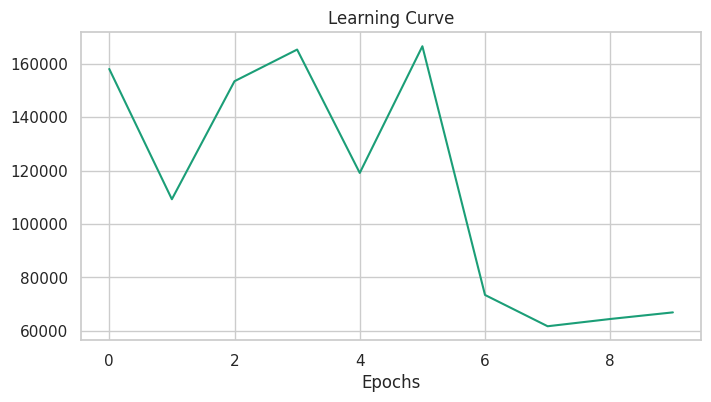

In [ ]:
# Get loss and epochs range
mse=history.history['loss']
iterations=range(epochs)

# Plotting the loss vs iterations
plt.figure(figsize=(8,4), dpi=100)
plt.plot(iterations, mse)
plt.xlabel("Epochs")
plt.title('Learning Curve');

In [ ]:
def model_forecast(model, series, window_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size))
    ds = ds.batch(32).prefetch(1)
    forecast = model.predict(ds)
    return forecast

# Perform forecast on test data
forecast = model_forecast(model, x_validation, window)
forecast = np.squeeze(forecast)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [ ]:
# Calculate the length of the forecast period by subtracting the window size minus one from the length of the validation data
# This ensures that the forecast period aligns correctly with the validation data and the model's window size
slice_length = len(x_validation) - (window - 1)

# Generate a range of dates spanning the length of the forecast period
predict_datetime = pd.date_range(
    df['date'].iloc[-slice_length], # The starting date for the forecast period
    periods=slice_length,           # The number of periods to generate
    freq='D'
)

# Create a DataFrame to hold the forecast results
df_forecast = pd.DataFrame({
    'date': pd.to_datetime(predict_datetime),       # Dates for the forecast period
    'price': forecast[-slice_length:],              # Forecasted prices for the last slice_length period
    'true price': df[-slice_length:]['price']       # Actual prices for the last slice_length period in the original DataFrame
})

In [ ]:
df_forecast.head()

,date,price,true price
3213,2020-10-20,11528.013672,11845.171933
3214,2020-10-21,12003.817383,12458.802238
3215,2020-10-22,12530.054688,12932.719539
3216,2020-10-23,12799.255859,12932.833654
3217,2020-10-24,13002.416016,13030.236787


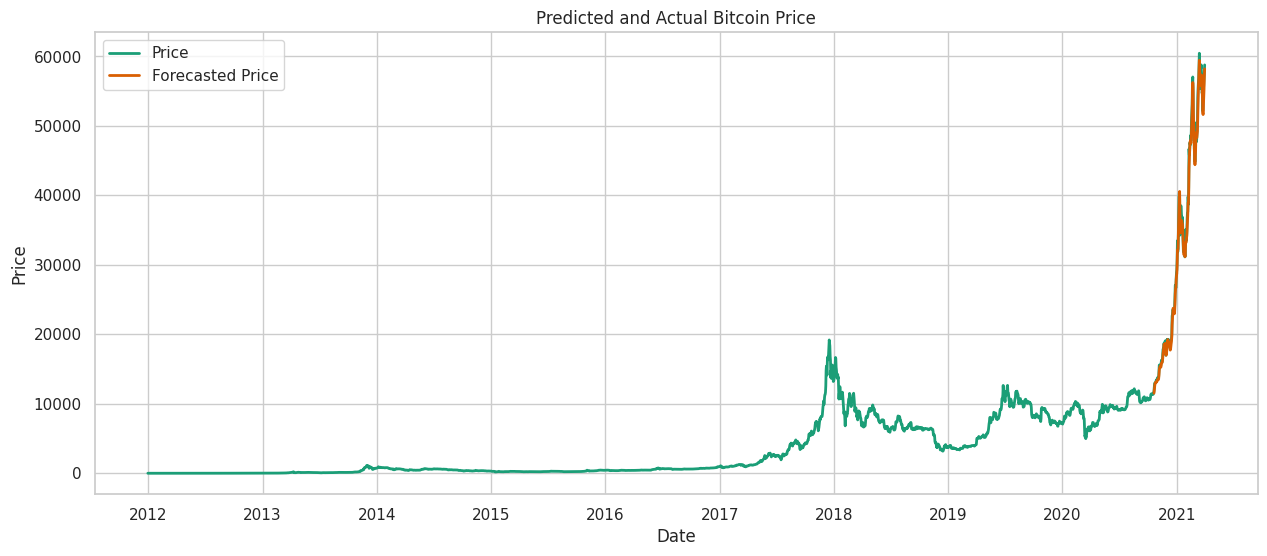

In [ ]:
plt.figure(figsize=(15, 6), dpi=100)
plt.plot(df['date'], df['price'], linewidth=2, label='Price')
plt.plot(df_forecast['date'], df_forecast['price'], linewidth=2, label='Forecasted Price')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Predicted and Actual Bitcoin Price")
plt.legend()
plt.show()

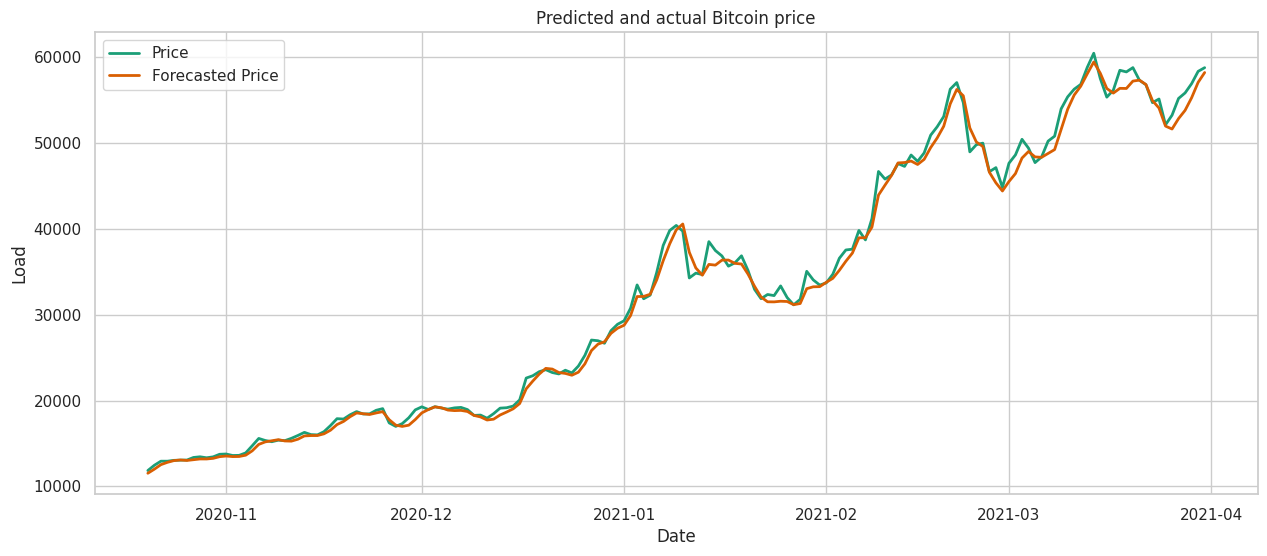

In [ ]:
#Plotting Forecasted
plt.figure(figsize=(15, 6), dpi=100)
plt.plot(df_forecast['date'], df_forecast['true price'], linewidth=2);
plt.plot(df_forecast['date'], df_forecast['price'], linewidth=2);
plt.xlabel("Date")
plt.ylabel("Load")
plt.title("Predicted and actual Bitcoin price")
plt.legend(['Price', 'Forecasted Price',]);

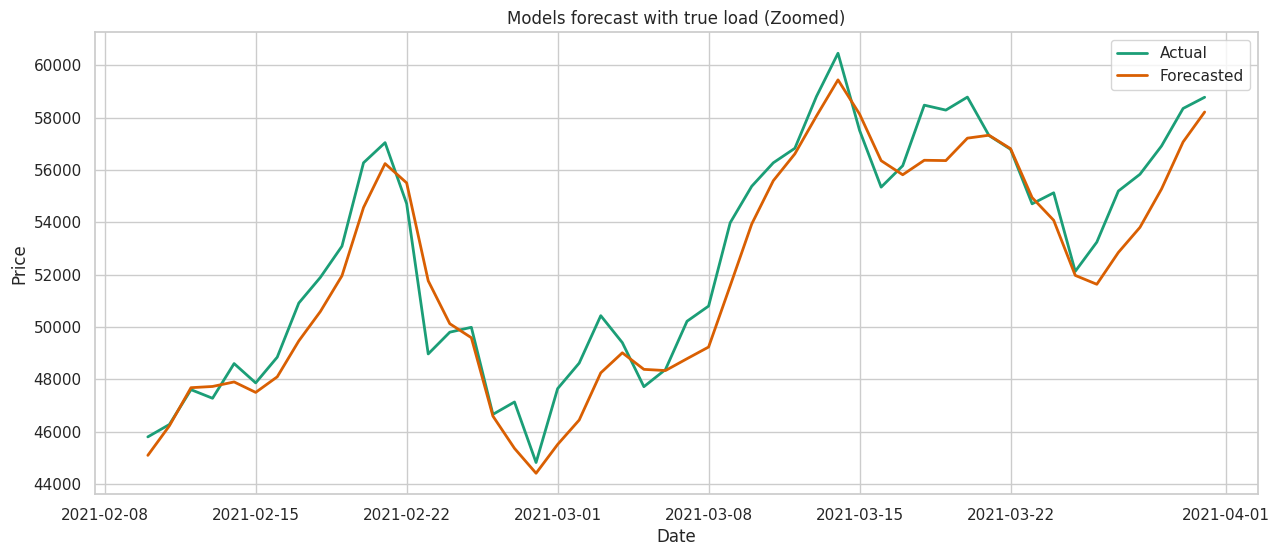

In [ ]:
# Plotting Zoomed version

window_size = 50

plt.figure(figsize=(15, 6), dpi=100)
plt.plot(df_forecast['date'][-window_size:], df_forecast['true price'][-window_size:], linewidth=2);
plt.plot(df_forecast['date'][-window_size:], df_forecast['price'][-window_size:], linewidth=2);

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Models forecast with true load (Zoomed)")
plt.legend(['Actual', 'Forecasted']);

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Extract true and predicted values
true_values = df_forecast['true price'].to_numpy()
predicted_values = df_forecast["price"].to_numpy()

# Calculate error metrics
mae = mean_absolute_error(true_values, predicted_values)
mse = mean_squared_error(true_values, predicted_values)
mape = mean_absolute_percentage_error(true_values, predicted_values)

# Print error metrics
print(f"Mean Squared Error of the forecast: {mse:,.2f}")
print(f"Mean Absolute Error of the forecast: {mae:,.2f}")
print(f"Mean Absolute Percentage Error of the forecast: {mape:.4f}")

Mean Squared Error of the forecast: 924,385.07
Mean Absolute Error of the forecast: 688.05
Mean Absolute Percentage Error of the forecast: 0.0202


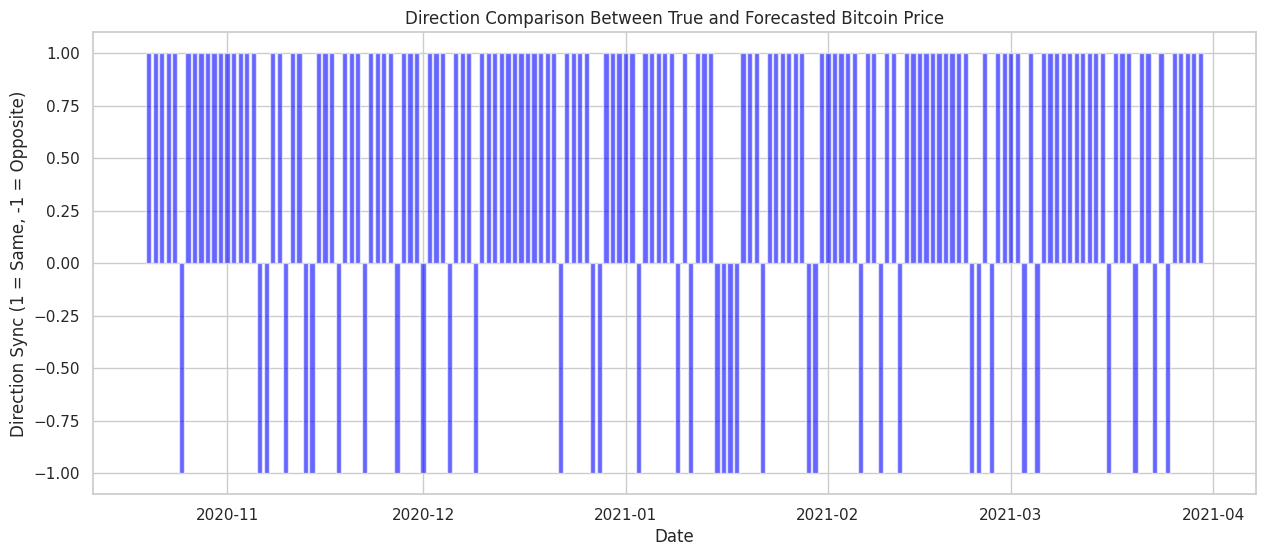

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the direction of each line
direction_true = np.sign(np.diff(df_forecast['true price']))
direction_forecast = np.sign(np.diff(df_forecast['price']))

# Compare the directions and assign 1 or -1
comparison = np.where(direction_true == direction_forecast, 1, -1)

# Since np.diff reduces the array length by 1, add a nan at the end to align with the original date array
comparison = np.append(comparison, np.nan)

# Plot the comparison
plt.figure(figsize=(15, 6), dpi=100)
plt.bar(df_forecast['date'], comparison, color='blue', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Direction Sync (1 = Same, -1 = Opposite)")
plt.title("Direction Comparison Between True and Forecasted Bitcoin Price")
plt.show()
